# Task 3 Quantitative Analysis Notebook

Project: Jurisdiction-Aware Credit Decision Governance Monitor

This notebook accompanies the report. It shows the analytical design of the
jurisdiction-aware tool using synthetic data. It intentionally treats the US and
EU as different computation modules under a shared evidence schema, not as one
global sensitive-data pipeline.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd

BASE = Path('.').resolve()
DATA = BASE.parent / 'data'
OUTPUTS = BASE.parent / 'outputs'
synthetic = pd.read_csv(DATA / 'Task3_Synthetic_Credit_Data.csv')
config = json.loads((OUTPUTS / 'Task3_Jurisdiction_Config.json').read_text())
synthetic.head()

,applicant_id,jurisdiction,age,income,credit_score,debt_to_income,employment_length,loan_amount,postcode_risk_band,thin_file_flag,income_instability_flag,model_score,decision,observed_default,gender_audit,age_band,protected_group_flag,audit_group,denial_feature_candidate
0,APP-00001,US,31,47455,720,0.329,3.4,21350,Low,1,0,0.5495,Declined,0,Male,26-35,0,Reference audit group,thin_file_flag
1,APP-00002,US,35,56634,763,0.261,2.8,26529,High,0,0,0.7106,Approved,1,Female,26-35,1,Protected audit group,postcode_risk_band
2,APP-00003,EU,34,63165,737,0.319,13.7,21617,Low,1,0,0.7096,Approved,0,Male,26-35,0,Reference audit group,thin_file_flag
3,APP-00004,EU,43,38978,553,0.325,8.0,14469,Low,1,0,0.1371,Declined,0,Female,36-45,1,Protected audit group,credit_score
4,APP-00005,US,32,64198,647,0.326,5.2,26957,Low,0,1,0.4112,Declined,0,Male,26-35,0,Reference audit group,income_instability_flag


## 1. Create US and EU data paths

In [2]:
protected_cols = ['age', 'gender_audit', 'age_band', 'protected_group_flag', 'audit_group']
us_processed = synthetic[synthetic['jurisdiction'].eq('US')].drop(columns=protected_cols)
eu_audit = synthetic[synthetic['jurisdiction'].eq('EU')].copy()

print('US processed columns:', list(us_processed.columns))
print('EU audit-only columns:', [c for c in protected_cols if c in eu_audit.columns])

US processed columns: ['applicant_id', 'jurisdiction', 'income', 'credit_score', 'debt_to_income', 'employment_length', 'loan_amount', 'postcode_risk_band', 'thin_file_flag', 'income_instability_flag', 'model_score', 'decision', 'observed_default', 'denial_feature_candidate']
EU audit-only columns: ['age', 'gender_audit', 'age_band', 'protected_group_flag', 'audit_group']


## 2. US module: SHAP-style attribution aid and reason-code mapping

In [3]:
reason_map = {
    'credit_score': ('AA-CR-01', 'Credit score below program threshold'),
    'debt_to_income': ('AA-DTI-02', 'Debt-to-income ratio too high'),
    'employment_length': ('AA-EMP-03', 'Insufficient length of employment history'),
    'loan_amount': ('AA-LTV-04', 'Requested credit amount high relative to verified income'),
    'thin_file_flag': ('AA-THIN-05', 'Limited credit file information'),
    'income_instability_flag': ('AA-INC-06', 'Income history appears unstable or difficult to verify'),
    'postcode_risk_band': ('REVIEW-PROXY', 'Manual review required: geographic proxy must not be used as a final consumer reason'),
}

declined = us_processed[us_processed['decision'].eq('Declined')].copy()
declined[['reason_code', 'reason_text']] = declined['denial_feature_candidate'].apply(lambda x: pd.Series(reason_map[x]))
rng = np.random.default_rng(1209)
declined['reason_confidence'] = np.clip(
    0.78
    - (declined['model_score'] - 0.42).abs() * 0.45
    - (declined['denial_feature_candidate'].eq('postcode_risk_band') * 0.28)
    - rng.normal(0, 0.05, len(declined)),
    0.05,
    0.98
)
declined['low_confidence_reason_flag'] = (
    (declined['reason_confidence'] < 0.58)
    | declined['denial_feature_candidate'].eq('postcode_risk_band')
)

declined.groupby(['reason_code', 'reason_text']).agg(
    count=('applicant_id', 'count'),
    low_confidence_rate=('low_confidence_reason_flag', 'mean')
).reset_index()

,reason_code,reason_text,count,low_confidence_rate
0,AA-CR-01,Credit score below program threshold,209,0.081340
1,AA-DTI-02,Debt-to-income ratio too high,77,0.012987
2,AA-EMP-03,Insufficient length of employment history,25,0.000000
3,AA-INC-06,Income history appears unstable or difficult to verify,26,0.000000
4,AA-LTV-04,Requested credit amount high relative to verified income,2,0.000000
5,AA-THIN-05,Limited credit file information,66,0.015152
6,REVIEW-PROXY,Manual review required: geographic proxy must not be used as a final consumer reason,116,1.000000


SHAP-style attribution is used only as an internal aid. The notebook never treats
feature attribution as a legally sufficient adverse action notice.

## 3. US module: proxy-risk analysis

In [4]:
denial_by_postcode = us_processed.groupby('postcode_risk_band')['decision'].apply(lambda s: (s == 'Declined').mean())
denial_by_thin = us_processed.groupby('thin_file_flag')['decision'].apply(lambda s: (s == 'Declined').mean())
proxy_summary = pd.DataFrame({
    'metric': ['Very High vs Low postcode denial gap', 'Thin-file denial gap'],
    'value': [
        denial_by_postcode.get('Very High', 0) - denial_by_postcode.get('Low', 0),
        denial_by_thin.get(1, 0) - denial_by_thin.get(0, 0)
    ]
})
proxy_summary

,metric,value
0,Very High vs Low postcode denial gap,0.317664
1,Thin-file denial gap,0.264865


## 4. EU module: controlled audit bias testing

In [5]:
eu_audit['approved_flag'] = eu_audit['decision'].eq('Approved').astype(int)
approval_rates = eu_audit.groupby('audit_group')['approved_flag'].mean()
approval_disparity_ratio = approval_rates.min() / approval_rates.max()

good = eu_audit['observed_default'].eq(0)
bad = eu_audit['observed_default'].eq(1)
fnr = eu_audit[good].groupby('audit_group')['decision'].apply(lambda s: (s == 'Declined').mean())
fpr = eu_audit[bad].groupby('audit_group')['decision'].apply(lambda s: (s == 'Approved').mean())

pd.DataFrame({
    'approval_rate': approval_rates,
    'false_negative_rate_good_borrowers': fnr,
    'false_positive_rate_bad_borrowers': fpr,
})

,approval_rate,false_negative_rate_good_borrowers,false_positive_rate_bad_borrowers
audit_group,,,
Protected audit group,0.139098,0.820896,0.015385
Reference audit group,0.400922,0.555556,0.107143


## 5. EU module: drift / PSI analysis

In [6]:
def psi(expected, actual, bins=10):
    breaks = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    if len(breaks) < 3:
        return 0.0
    e_bins = pd.cut(expected, bins=breaks, include_lowest=True, duplicates='drop')
    a_bins = pd.cut(actual, bins=breaks, include_lowest=True, duplicates='drop')
    e = e_bins.value_counts(normalize=True, sort=False).replace(0, 0.0001)
    a = a_bins.value_counts(normalize=True, sort=False).replace(0, 0.0001).reindex(e.index, fill_value=0.0001)
    return float(((a - e) * np.log(a / e)).sum())

current = eu_audit.copy()
current.loc[current['audit_group'].eq('Protected audit group'), 'debt_to_income'] = np.clip(
    current.loc[current['audit_group'].eq('Protected audit group'), 'debt_to_income'] + 0.065, 0, 0.95
)
current.loc[:, 'model_score'] = np.clip(
    current['model_score'] - current['protected_group_flag'] * 0.045 + np.random.default_rng(333).normal(0, 0.018, len(current)),
    0,
    1
)

pd.DataFrame({
    'metric': ['Model score PSI', 'Debt-to-income PSI'],
    'value': [psi(eu_audit['model_score'], current['model_score']), psi(eu_audit['debt_to_income'], current['debt_to_income'])]
})

,metric,value
0,Model score PSI,0.004665
1,Debt-to-income PSI,0.053720


## 6. Sensitivity analysis and exported evidence

In [7]:
sensitivity = pd.read_csv(OUTPUTS / 'Task3_Sensitivity_Results.csv')
us_evidence = pd.read_csv(OUTPUTS / 'Task3_Output_US_Evidence.csv')
eu_evidence = pd.read_csv(OUTPUTS / 'Task3_Output_EU_Evidence.csv')

display(sensitivity.head())
display(us_evidence)
display(eu_evidence)

,approval_threshold,alert_threshold,eu_approval_disparity_ratio,us_proxy_denial_gap,estimated_human_review_workload,bias_alert
0,0.52,0.05,0.339,0.348,0.376,Yes
1,0.52,0.08,0.339,0.348,0.376,Yes
2,0.52,0.10,0.339,0.348,0.376,Yes
3,0.56,0.05,0.347,0.318,0.369,Yes
4,0.56,0.08,0.347,0.318,0.369,Yes


,jurisdiction,model_version,data_version,rule_version,risk_signal,evidence_generated,confidence_level,required_owner,required_action,deadline,escalation_level,audit_log_reference
0,US,credit-demo-v1.0,synthetic-2026-05,US-ADV-001@1.0,Adverse action reason-code quality,521 declined applications assessed; 25.9% flagged for low-confidence or proxy-sensitive reason mapping.,Medium,US Compliance Lead,Review low-confidence reason-code samples before consumer-facing notice finalization.,T+5 business days,Level 3 - Model governance review,AUD-US-ADV-0001
1,US,credit-demo-v1.0,synthetic-2026-05,US-PROXY-002@1.0,Potential proxy discrimination / digital redlining signal,Very High vs Low postcode denial-rate gap = 31.8%; thin-file denial-rate gap = 26.5%.,Medium,Fair Lending Review Counsel,Open privileged fair lending review; test whether geography and thin-file variables are acting as protected-class proxies.,T+10 business days,Level 3 - Model governance review,AUD-US-PROXY-0002
2,US,credit-demo-v1.0,synthetic-2026-05,US-DATA-003@1.0,Protected-attribute hard-drop control,"US processed file excludes age, gender_audit, age_band, protected_group_flag and audit_group.",High,Data Governance Lead,Preserve physical separation between live explanation path and any privileged demographic audit.,Continuous,Level 0 - No action,AUD-US-DATA-0003


,jurisdiction,model_version,data_version,rule_version,risk_signal,evidence_generated,confidence_level,required_owner,required_action,deadline,escalation_level,audit_log_reference
0,EU,credit-demo-v1.0,synthetic-2026-05,EU-HRAI-001@1.0,High-risk AI governance evidence gate,Pre-deployment evidence completeness score = 87.5%; missing item: fundamental rights impact assessment owner.,High,EU AI Governance Lead,Do not approve EU production launch until missing governance owner is assigned and logged.,Before deployment approval,Level 3 - Model governance review,AUD-EU-HRAI-0001
1,EU,credit-demo-v1.0,synthetic-2026-05,EU-BIAS-002@1.0,Controlled audit bias testing,Approval-rate disparity ratio = 0.35; FNR gap = 26.5%; FPR gap = 9.2%.,Medium,EU Model Risk Lead,Review bias testing result in segregated audit environment and document remediation decision.,T+10 business days,Level 3 - Model governance review,AUD-EU-BIAS-0002
2,EU,credit-demo-v1.0,synthetic-2026-05,EU-DRIFT-003@1.0,Post-deployment drift monitoring,Model-score PSI = 0.005; debt-to-income PSI = 0.054 under protected-group shift scenario.,Medium,Model Monitoring Lead,Open drift ticket and compare against monthly production monitoring once real data is connected.,Monthly monitoring cycle,Level 2 - Sampled review,AUD-EU-DRIFT-0003


## 7. Static chart outputs

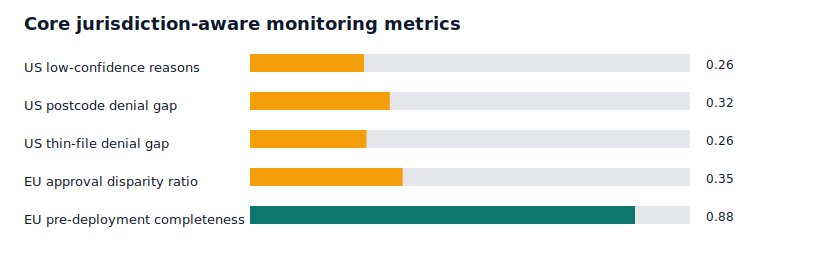

,approval_threshold,alert_threshold,estimated_human_review_workload,scenario
0,0.52,0.05,0.376,approval 0.52 / alert 0.05
1,0.52,0.08,0.376,approval 0.52 / alert 0.08
2,0.52,0.10,0.376,approval 0.52 / alert 0.10
3,0.56,0.05,0.369,approval 0.56 / alert 0.05
4,0.56,0.08,0.369,approval 0.56 / alert 0.08
5,0.56,0.10,0.369,approval 0.56 / alert 0.10
6,0.60,0.05,0.372,approval 0.60 / alert 0.05
7,0.60,0.08,0.372,approval 0.60 / alert 0.08


In [8]:
from IPython.display import SVG, display

metrics = json.loads((OUTPUTS / 'Task3_Run_Metrics.json').read_text())
chart_values = [
    ('US low-confidence reasons', metrics['us_low_confidence_reason_rate']),
    ('US postcode denial gap', metrics['us_high_postcode_denial_gap']),
    ('US thin-file denial gap', metrics['us_thin_file_denial_gap']),
    ('EU approval disparity ratio', metrics['eu_approval_disparity_ratio']),
    ('EU pre-deployment completeness', metrics['eu_predeployment_completeness']),
]

def bar_svg(values, title, width=820, row_height=38):
    height = 72 + row_height * len(values)
    label_x = 24
    bar_x = 250
    bar_w = 440
    rows = []
    for i, (label, value) in enumerate(values):
        y = 54 + i * row_height
        fill = '#0f766e' if value >= 0.80 else ('#f59e0b' if value >= 0.20 else '#ef4444')
        rows.append(f"<text x='{label_x}' y='{y + 18}' font-size='13' fill='#111827'>{label}</text>")
        rows.append(f"<rect x='{bar_x}' y='{y}' width='{bar_w}' height='18' fill='#e5e7eb'/>")
        rows.append(f"<rect x='{bar_x}' y='{y}' width='{min(value, 1.0) * bar_w:.1f}' height='18' fill='{fill}'/>")
        rows.append(f"<text x='{bar_x + bar_w + 16}' y='{y + 15}' font-size='12' fill='#111827'>{value:.2f}</text>")
    body = ''.join(rows)
    return f"<svg xmlns='http://www.w3.org/2000/svg' width='{width}' height='{height}'><rect width='100%' height='100%' fill='white'/><text x='24' y='30' font-size='18' font-weight='700' fill='#0f172a'>{title}</text>{body}</svg>"

display(SVG(bar_svg(chart_values, 'Core jurisdiction-aware monitoring metrics')))

workload = sensitivity[['approval_threshold', 'alert_threshold', 'estimated_human_review_workload']].copy()
workload['scenario'] = workload.apply(lambda r: f"approval {r.approval_threshold:.2f} / alert {r.alert_threshold:.2f}", axis=1)
display(workload.head(8))